In [1]:
import os
import re
import json
import string
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_json(
    r"D:/Old laptop data/Udemy/Role Play - NLP Engineer/dataset/News_Category_Dataset_v3.json",
    lines=True
)

df.head()

,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


#### EDA

In [8]:
df.shape

(209527, 6)

In [9]:
df.columns

Index(['link', 'headline', 'category', 'short_description', 'authors', 'date'], dtype='str')

In [10]:
df.isnull().sum()

link                 0
headline             0
category             0
short_description    0
authors              0
date                 0
dtype: int64

In [11]:
df.dtypes

link                            str
headline                        str
category                        str
short_description               str
authors                         str
date                 datetime64[us]
dtype: object

In [12]:
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 13


In [13]:
df["category"].value_counts()

category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
COMEDY             5400
SPORTS             5077
BLACK VOICES       4583
HOME & LIVING      4320
PARENTS            3955
THE WORLDPOST      3664
WEDDINGS           3653
WOMEN              3572
CRIME              3562
IMPACT             3484
DIVORCE            3426
WORLD NEWS         3299
MEDIA              2944
WEIRD NEWS         2777
GREEN              2622
WORLDPOST          2579
RELIGION           2577
STYLE              2254
SCIENCE            2206
TECH               2104
TASTE              2096
MONEY              1756
ARTS               1509
ENVIRONMENT        1444
FIFTY              1401
GOOD NEWS          1398
U.S. NEWS          1377
ARTS & CULTURE     1339
COLLEGE            1144
LATINO VOICES      1130
CULTURE & ARTS     1074
EDUCATI

In [14]:
df["category"].unique()

<ArrowStringArray>
[     'U.S. NEWS',         'COMEDY',      'PARENTING',     'WORLD NEWS',
 'CULTURE & ARTS',           'TECH',         'SPORTS',  'ENTERTAINMENT',
       'POLITICS',     'WEIRD NEWS',    'ENVIRONMENT',      'EDUCATION',
          'CRIME',        'SCIENCE',       'WELLNESS',       'BUSINESS',
 'STYLE & BEAUTY',   'FOOD & DRINK',          'MEDIA',   'QUEER VOICES',
  'HOME & LIVING',          'WOMEN',   'BLACK VOICES',         'TRAVEL',
          'MONEY',       'RELIGION',  'LATINO VOICES',         'IMPACT',
       'WEDDINGS',        'COLLEGE',        'PARENTS', 'ARTS & CULTURE',
          'STYLE',          'GREEN',          'TASTE', 'HEALTHY LIVING',
  'THE WORLDPOST',      'GOOD NEWS',      'WORLDPOST',          'FIFTY',
           'ARTS',        'DIVORCE']
Length: 42, dtype: str

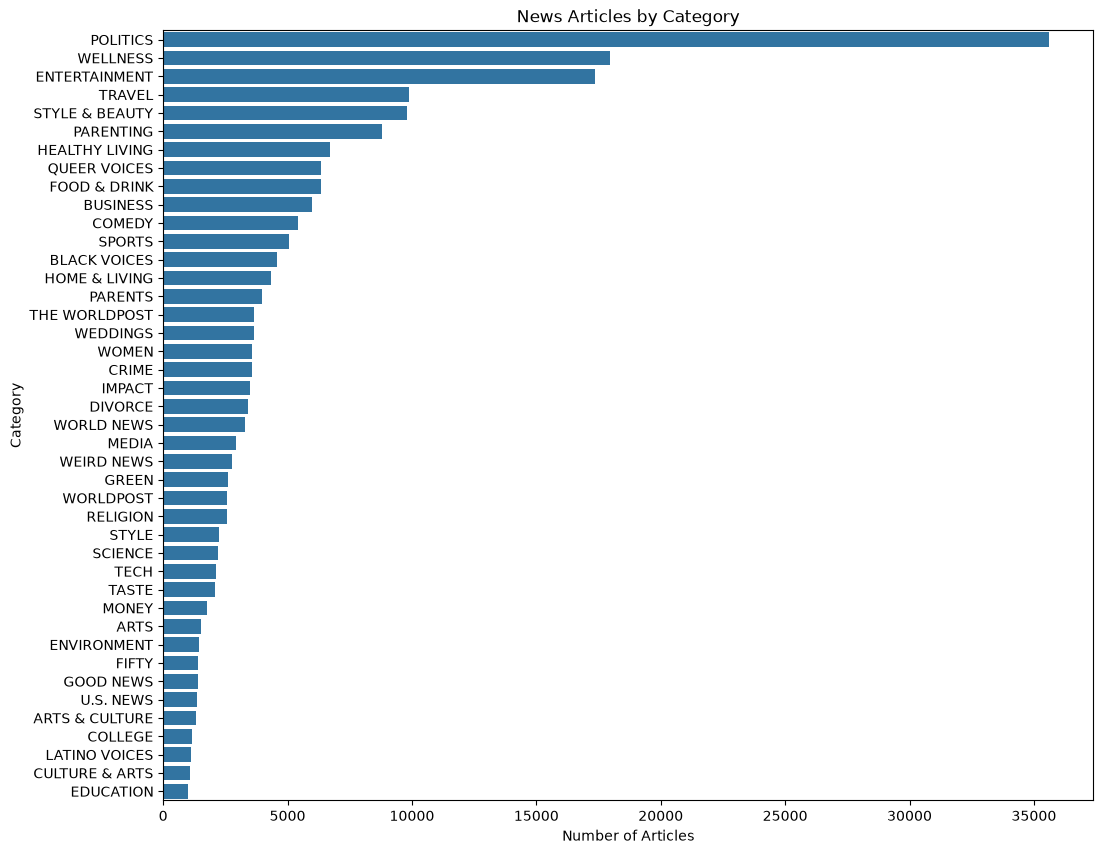

In [15]:
plt.figure(figsize=(12, 10))

category_counts = df["category"].value_counts()

sns.barplot(
    x=category_counts.values,
    y=category_counts.index
)

plt.title("News Articles by Category")
plt.xlabel("Number of Articles")
plt.ylabel("Category")
plt.show()

#### Politics has far more cantegories than the 2nd most frequent category of wellness and the rest of them in the dataset

In [16]:
print("Missing headlines:", df["headline"].isna().sum())
print("Missing descriptions:", df["short_description"].isna().sum())

Missing headlines: 0
Missing descriptions: 0


In [17]:
print(
    "Empty descriptions:",
    (df["short_description"].fillna("").str.strip() == "").sum()
)

Empty descriptions: 19712


In [18]:
df.loc[
    df["short_description"].fillna("").str.strip() == "",
    ["category", "headline", "short_description"]
].head(20)

,category,headline,short_description
20773,COMEDY,The Big Blue Wave,
21523,WORLD NEWS,"Inside Rukban Camp, One Of Syria’s Most Desper...",
22793,WORLD NEWS,Syrian Refugees Return From Lebanon Only To Fl...,
32223,TASTE,Your Guide To The Best BBQ In St. Louis Accord...,
34488,COMEDY,The Bechdel Test,
35584,WOMEN,Note: This content has been removed.,
35692,WOMEN,Note: This content has been removed.,
40313,POLITICS,Fired U.S. Attorney Preet Bharara Said to Have...,
43295,HEALTHY LIVING,"Love Needs To Be Remembered, Restored and Renewed",
43296,WORLDPOST,A New American Strategy in the Middle East,


In [19]:
print("Duplicate complete rows:", df.duplicated().sum())

print(
    "Duplicate headlines:",
    df["headline"].duplicated().sum()
)

Duplicate complete rows: 13
Duplicate headlines: 1531


In [23]:
df["headline_words"] = df["headline"].str.split().str.len()

df["headline_words"].describe()

count    209527.000000
mean          9.600744
std           3.068507
min           0.000000
25%           8.000000
50%          10.000000
75%          12.000000
max          44.000000
Name: headline_words, dtype: float64

In [24]:
df["description_words"] = (
    df["short_description"]
    .fillna("")
    .str.split()
    .str.len()
)

df["description_words"].describe()

count    209527.000000
mean         19.669026
std          14.152783
min           0.000000
25%          10.000000
50%          19.000000
75%          24.000000
max         243.000000
Name: description_words, dtype: float64

In [25]:
print(
    "Empty headlines:",
    df["headline"].fillna("").str.strip().eq("").sum()
)

Empty headlines: 6


In [26]:
df.loc[
    df["headline"].fillna("").str.strip().eq(""),
    ["category", "headline", "short_description"]
].head(20)

,category,headline,short_description
90944,POLITICS,,
95567,RELIGION,,Let everyone not wrapped in tired and disprove...
103675,WORLDPOST,,
109100,BUSINESS,,
110153,MEDIA,,
122145,QUEER VOICES,,


#### From the above output it can be seen that there are 13 rows that are exactly the same. These can be removed safely

In [20]:
df["date"] = pd.to_datetime(df["date"])

print(df["date"].min())
print(df["date"].max())

2012-01-28 00:00:00
2022-09-23 00:00:00


In [21]:
df["date"].dt.year.value_counts().sort_index()

date
2012    31355
2013    34583
2014    32339
2015    32006
2016    32098
2017    29889
2018     9734
2019     2005
2020     2054
2021     2066
2022     1398
Name: count, dtype: int64

In [ ]:
#### Understanding the different categories in the dataset

In [22]:
print("Number of categories:", df["category"].nunique())

print("\nAll categories:")
print(sorted(df["category"].unique()))

Number of categories: 42

All categories:
['ARTS', 'ARTS & CULTURE', 'BLACK VOICES', 'BUSINESS', 'COLLEGE', 'COMEDY', 'CRIME', 'CULTURE & ARTS', 'DIVORCE', 'EDUCATION', 'ENTERTAINMENT', 'ENVIRONMENT', 'FIFTY', 'FOOD & DRINK', 'GOOD NEWS', 'GREEN', 'HEALTHY LIVING', 'HOME & LIVING', 'IMPACT', 'LATINO VOICES', 'MEDIA', 'MONEY', 'PARENTING', 'PARENTS', 'POLITICS', 'QUEER VOICES', 'RELIGION', 'SCIENCE', 'SPORTS', 'STYLE', 'STYLE & BEAUTY', 'TASTE', 'TECH', 'THE WORLDPOST', 'TRAVEL', 'U.S. NEWS', 'WEDDINGS', 'WEIRD NEWS', 'WELLNESS', 'WOMEN', 'WORLD NEWS', 'WORLDPOST']


#### From the above output it can be seen that there are 42 unique categories but some are very similar like for e.g. 'ARTS', 'ARTS & CULTURE', 'CULTURE & ARTS'

#### The insights that we have from our EDA so far are:
1. There are no missing/NaN values in headlines and descriptions columns but upon close inspection we found 6 and 19712 empty strings respectively in headlines and descriptions.
2. There are 13 exactly same duplicate rows.
3. There are 1531 duplicate headlines which will need further inspection.
4. The years range from 2012 to 2022 (historical dataset).
5. There is a sharp decrease in yearly entries after 2017.
6. Average headline length is 9.6 words.
7. Average description length is 19.7 words.

In [27]:
## Investigating empty descriptions by category
empty_description_by_category = (
    df["short_description"]
    .fillna("")
    .str.strip()
    .eq("")
    .groupby(df["category"])
    .sum()
    .sort_values(ascending=False)
)

print(empty_description_by_category)

category
POLITICS          3161
ENTERTAINMENT     2588
HEALTHY LIVING    1429
WORLDPOST         1337
BUSINESS           860
COMEDY             758
QUEER VOICES       744
CRIME              730
RELIGION           698
STYLE              687
SPORTS             663
ARTS               646
GREEN              576
MEDIA              540
TRAVEL             479
WEIRD NEWS         461
BLACK VOICES       406
SCIENCE            403
PARENTS            399
IMPACT             398
WOMEN              388
GOOD NEWS          359
FIFTY              359
COLLEGE            223
TASTE              156
EDUCATION          112
LATINO VOICES      108
STYLE & BEAUTY      12
CULTURE & ARTS      11
FOOD & DRINK         9
HOME & LIVING        3
WORLD NEWS           2
WELLNESS             2
ENVIRONMENT          2
TECH                 1
MONEY                1
PARENTING            1
ARTS & CULTURE       0
DIVORCE              0
THE WORLDPOST        0
WEDDINGS             0
U.S. NEWS            0
Name: short_description, 

In [28]:
category_empty_stats = pd.DataFrame({
    "total_articles": df["category"].value_counts(),
    "empty_descriptions": empty_description_by_category
})

category_empty_stats["empty_description_pct"] = (
    category_empty_stats["empty_descriptions"]
    / category_empty_stats["total_articles"]
    * 100
)

category_empty_stats = category_empty_stats.sort_values(
    "empty_description_pct",
    ascending=False
)

category_empty_stats

,total_articles,empty_descriptions,empty_description_pct
category,,,
WORLDPOST,2579,1337,51.841799
ARTS,1509,646,42.809808
STYLE,2254,687,30.479148
RELIGION,2577,698,27.085759
GOOD NEWS,1398,359,25.679542
FIFTY,1401,359,25.624554
GREEN,2622,576,21.967963
HEALTHY LIVING,6694,1429,21.347475
CRIME,3562,730,20.494104


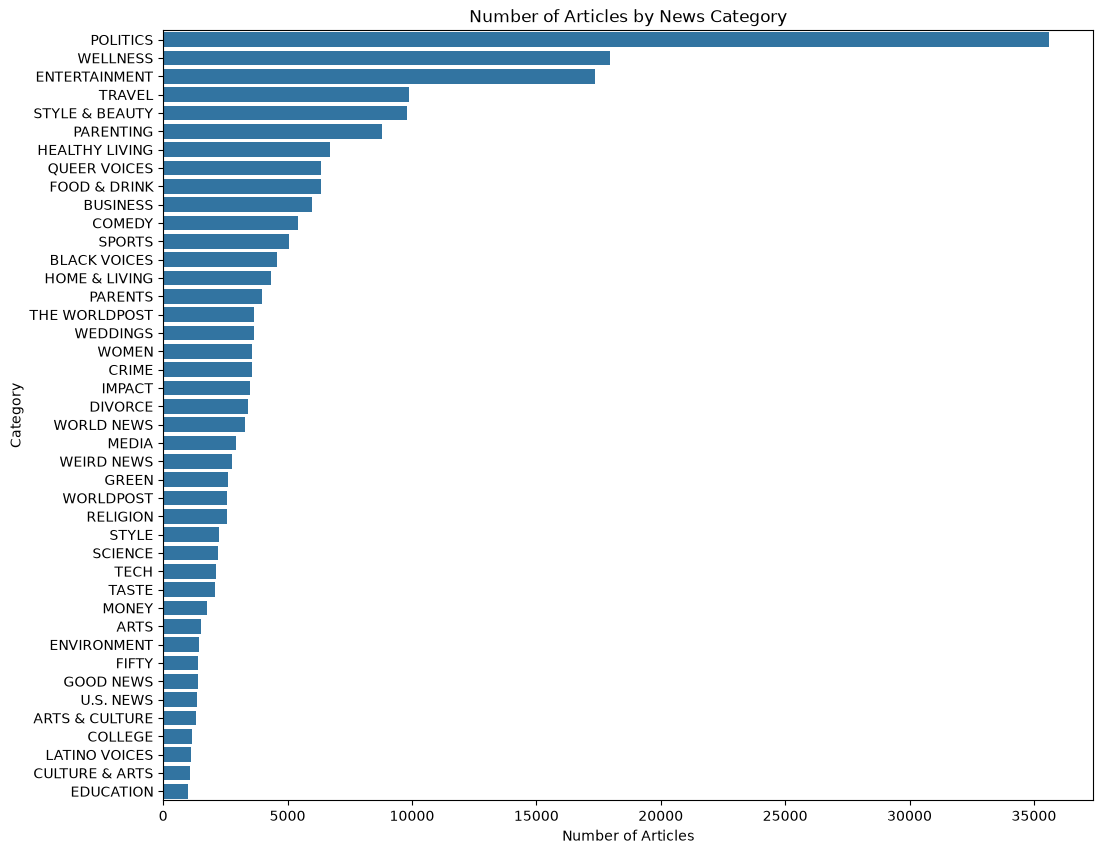

In [30]:
category_counts = df["category"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 10))

sns.barplot(
    x=category_counts.values,
    y=category_counts.index
)

plt.title("Number of Articles by News Category")
plt.xlabel("Number of Articles")
plt.ylabel("Category")

plt.show()

#### The dataset exhibits significant class imbalance, with POLITICS containing substantially more articles than the smallest categories such as EDUCATION, CULTURE & ARTS, and COLLEGE. Therefore, model evaluation should consider macro-averaged metrics such as precision, recall, and F1-score rather than relying solely on accuracy.